In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme()

In [2]:
np.random.seed(42)

n = 300

dataset = pd.DataFrame({
    'square_footage': np.random.randint(500, 4000, n),
    'bedrooms': np.random.randint(1, 6, n),
    'baths': np.random.randint(1, 5, n),
    'number_doors': np.random.randint(2, 12, n),
    'hardwood_floors': np.random.randint(0, 2, n),
    'city_center': np.random.uniform(1, 30, n),
    'supermarket_proximity': np.random.uniform(0.5, 10, n),
    'transit_accessibility': np.random.uniform(1, 10, n),
    'school_proximity': np.random.uniform(0.5, 10, n),
    'crime_rate': np.random.uniform(1, 10, n),
    'property_age': np.random.randint(1, 80, n),
    'garage': np.random.randint(0, 4, n),
    'garden': np.random.randint(0, 2, n),
    'parking': np.random.randint(0, 4, n),
    'property_tax': np.random.randint(1000, 15000, n),
    'house_condition': np.random.randint(1, 6, n),
    'price': np.random.randint(100000, 1500000, n)
})

print(dataset.head())
print("\nShape:", dataset.shape)

   square_footage  bedrooms  baths  number_doors  hardwood_floors  \
0            3674         4      3             7                1   
1            1360         1      4             3                1   
2            1794         1      1             3                0   
3            1630         2      1             3                1   
4            1595         1      3             4                0   

   city_center  supermarket_proximity  transit_accessibility  \
0     8.728453               9.162442               4.361587   
1    22.233353               9.691357               5.738493   
2     8.271189               2.261859               2.010739   
3    19.359844               4.889924               1.023256   
4    15.333942               0.511702               6.741867   

   school_proximity  crime_rate  property_age  garage  garden  parking  \
0          5.212454    3.288898            46       1       1        1   
1          0.620791    8.373296            21       

In [3]:
print(dataset.isnull().sum())

square_footage           0
bedrooms                 0
baths                    0
number_doors             0
hardwood_floors          0
city_center              0
supermarket_proximity    0
transit_accessibility    0
school_proximity         0
crime_rate               0
property_age             0
garage                   0
garden                   0
parking                  0
property_tax             0
house_condition          0
price                    0
dtype: int64


In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(dataset)

print(X_scaled[:5])

[[ 1.34075375  0.72673497  0.57751064  0.17478529  1.04780824 -0.78749561
   1.45505734 -0.36643758 -0.00830344 -0.80945062  0.32765701 -0.4739827
   1.12815215 -0.43224121  1.2143715  -0.09244784  1.49701567]
 [-0.98813305 -1.34965065  1.46145551 -1.22349704  1.04780824  0.74343424
   1.6578687   0.18038169 -1.66980851  1.11559011 -0.80636587  1.29241246
   1.12815215 -1.33904095  0.89163759 -0.09244784 -0.2868247 ]
 [-0.55134097 -1.34965065 -1.19037908 -1.22349704 -0.95437311 -0.83933157
  -1.19095859 -1.30004479  1.69800941  1.32197485  0.23693518 -0.4739827
  -0.88640526 -1.33904095 -1.21430482 -0.82229924  0.03314717]
 [-0.71639604 -0.65752211 -1.19037908 -1.22349704  1.04780824  0.41769019
  -0.18323189 -1.69221017  0.5946759   0.11438162 -1.25997503 -0.4739827
  -0.88640526 -1.33904095 -1.48849448 -1.55215064  1.43298846]
 [-0.75162121 -1.34965065  0.57751064 -0.87392646 -0.95437311 -0.03869039
  -1.86205304  0.57885802 -0.62406468 -0.84346497  1.32559715 -1.35718028
   1.128152

In [5]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print("PCA shape:", X_pca.shape)

PCA shape: (300, 17)


In [6]:
explained_variance = pca.explained_variance_ratio_

for i, value in enumerate(explained_variance):
    print(
        f"PC{i+1}: {value * 100:.2f}%"
    )

PC1: 8.48%
PC2: 7.78%
PC3: 7.33%
PC4: 7.01%
PC5: 6.96%
PC6: 6.52%
PC7: 6.20%
PC8: 5.99%
PC9: 5.82%
PC10: 5.58%
PC11: 5.35%
PC12: 5.08%
PC13: 4.90%
PC14: 4.63%
PC15: 4.42%
PC16: 4.27%
PC17: 3.68%


In [7]:
cumulative_variance = np.cumsum(
    explained_variance
)

for i, value in enumerate(cumulative_variance):
    print(
        f"PC{i+1}: {value * 100:.2f}%"
    )

PC1: 8.48%
PC2: 16.26%
PC3: 23.60%
PC4: 30.60%
PC5: 37.56%
PC6: 44.08%
PC7: 50.28%
PC8: 56.27%
PC9: 62.08%
PC10: 67.66%
PC11: 73.01%
PC12: 78.10%
PC13: 83.00%
PC14: 87.63%
PC15: 92.05%
PC16: 96.32%
PC17: 100.00%


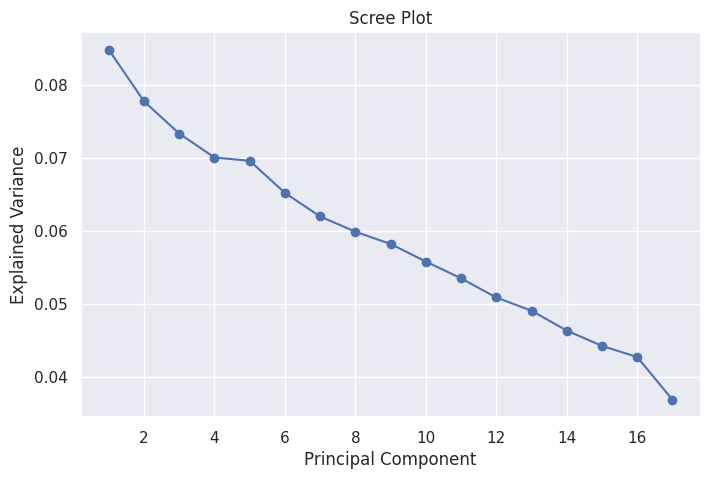

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker='o'
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")
plt.title("Scree Plot")

plt.show()

In [9]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[
        f'PC{i+1}'
        for i in range(len(dataset.columns))
    ],
    index=dataset.columns
)

print(loadings)

                            PC1       PC2       PC3       PC4       PC5  \
square_footage        -0.194989  0.246080 -0.083859 -0.030413  0.075803   
bedrooms              -0.087369  0.445269 -0.124053 -0.171271  0.131836   
baths                 -0.141378  0.236737 -0.044618  0.285118 -0.394958   
number_doors           0.312315  0.387525  0.350809  0.161574 -0.088536   
hardwood_floors        0.125000 -0.028030 -0.214932 -0.220126 -0.010055   
city_center            0.265172  0.034251  0.333020 -0.384188  0.236271   
supermarket_proximity  0.245130 -0.127992 -0.288459  0.182649 -0.089518   
transit_accessibility -0.155600  0.237126 -0.232163 -0.352845 -0.096473   
school_proximity       0.151635 -0.230341  0.060654  0.153348  0.316447   
crime_rate            -0.142494  0.103154  0.016116  0.035528  0.602656   
property_age          -0.302802 -0.244628  0.471256  0.069665 -0.026512   
garage                 0.496293 -0.041333  0.252680  0.002831 -0.037694   
garden                -0.

In [10]:
pc1 = loadings['PC1'].abs().sort_values(
    ascending=False
)

print("Most important features in PC1:")
print(pc1)

Most important features in PC1:
garage                   0.496293
garden                   0.427968
number_doors             0.312315
property_age             0.302802
city_center              0.265172
supermarket_proximity    0.245130
price                    0.210966
property_tax             0.207362
square_footage           0.194989
transit_accessibility    0.155600
school_proximity         0.151635
crime_rate               0.142494
baths                    0.141378
hardwood_floors          0.125000
parking                  0.101210
bedrooms                 0.087369
house_condition          0.066163
Name: PC1, dtype: float64


In [11]:
pc2 = loadings['PC2'].abs().sort_values(
    ascending=False
)

print("Most important features in PC2:")
print(pc2)

Most important features in PC2:
property_tax             0.552058
bedrooms                 0.445269
number_doors             0.387525
square_footage           0.246080
property_age             0.244628
transit_accessibility    0.237126
baths                    0.236737
school_proximity         0.230341
supermarket_proximity    0.127992
garden                   0.119254
crime_rate               0.103154
parking                  0.098136
house_condition          0.060504
price                    0.053486
garage                   0.041333
city_center              0.034251
hardwood_floors          0.028030
Name: PC2, dtype: float64


In [12]:
pca_df = pd.DataFrame(
    X_pca,
    columns=[
        f'PC{i+1}'
        for i in range(X_pca.shape[1])
    ]
)

combined = pd.concat(
    [dataset.reset_index(drop=True), pca_df],
    axis=1
)

correlation = combined.corr()

feature_pc_corr = correlation.loc[
    dataset.columns,
    pca_df.columns
]

print(feature_pc_corr)

                            PC1       PC2       PC3       PC4       PC5  \
square_footage        -0.234181  0.282938 -0.093638 -0.033191  0.082459   
bedrooms              -0.104930  0.511962 -0.138520 -0.186912  0.143411   
baths                 -0.169794  0.272196 -0.049821  0.311157 -0.429634   
number_doors           0.375089  0.445569  0.391721  0.176330 -0.096309   
hardwood_floors        0.150125 -0.032228 -0.239997 -0.240229 -0.010938   
city_center            0.318470  0.039381  0.371857 -0.419274  0.257015   
supermarket_proximity  0.294400 -0.147162 -0.322100  0.199329 -0.097378   
transit_accessibility -0.186875  0.272643 -0.259238 -0.385068 -0.104943   
school_proximity       0.182113 -0.264842  0.067727  0.167352  0.344230   
crime_rate            -0.171135  0.118604  0.017995  0.038772  0.655568   
property_age          -0.363664 -0.281269  0.526215  0.076027 -0.028840   
garage                 0.596045 -0.047524  0.282148  0.003090 -0.041004   
garden                -0.

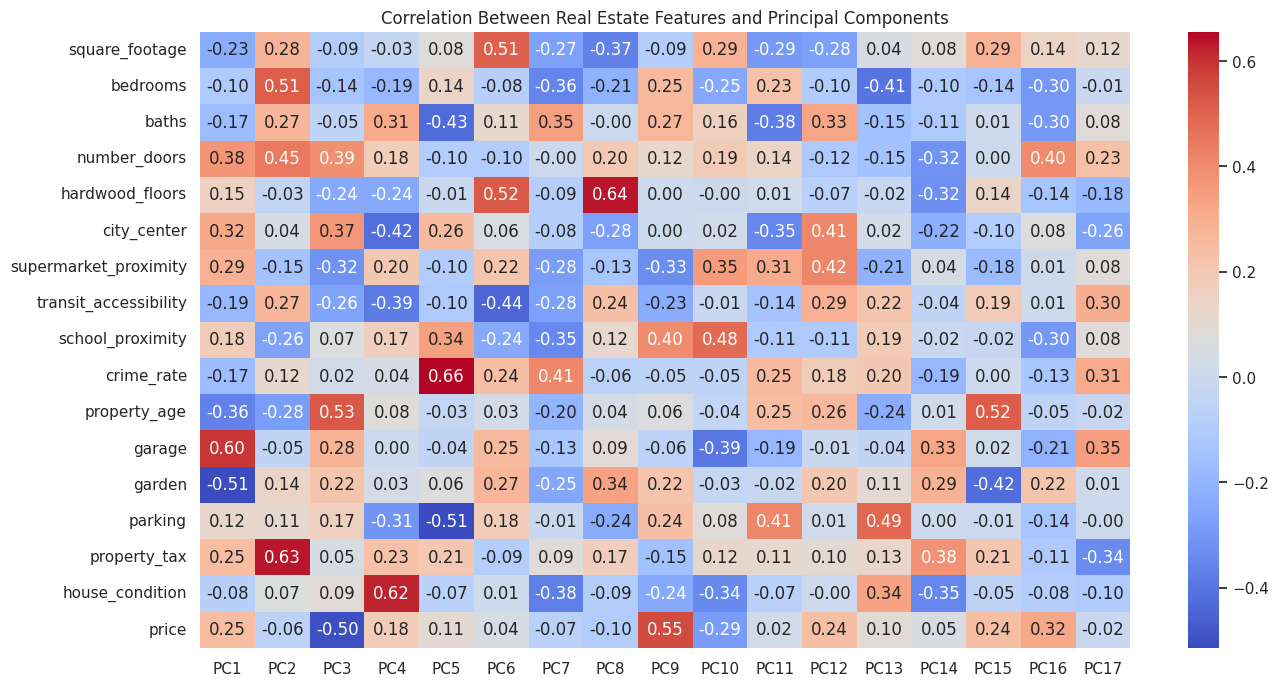

In [13]:
plt.figure(figsize=(15, 8))

sns.heatmap(
    feature_pc_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    "Correlation Between Real Estate Features and Principal Components"
)

plt.show()

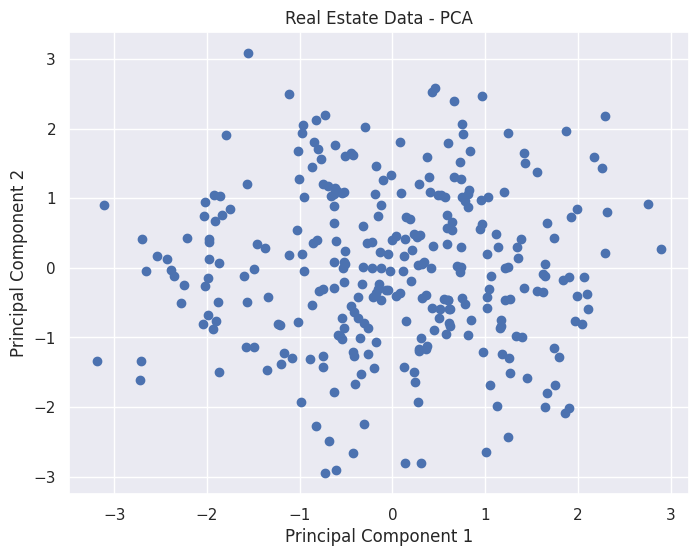

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Real Estate Data - PCA")

plt.show()